# Statistical Comparison of Transfer Learning Models
PM25Vision Dataset - ResNet50 vs EfficientNetB0 vs VGG16

## Overview
This notebook compares the performance of three pre-trained CNN models trained on the PM25Vision dataset.
- **Models**: ResNet50, EfficientNetB0, VGG16
- **Data**: PM25Vision dataset with 6 AQI classes
- **Purpose**: Statistical comparison and visualization of model performance

In [7]:
# Import Required Libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (12, 6)
rcParams['font.size'] = 10

In [8]:
# Load Results from All Models
models = ['resnet50', 'efficientnetb0', 'vgg16']
results = {}

print("Loading results from all models...\n")
for model_key in models:
    try:
        with open(f'{model_key}_results.json', 'r') as f:
            results[model_key] = json.load(f)
        print(f"✓ Loaded: {results[model_key]['model']}")
    except FileNotFoundError:
        print(f"✗ Not found: {model_key}_results.json")
        print(f"  Please ensure all three models have been trained first.")
        raise

print(f"\nSuccessfully loaded {len(results)} models")

Loading results from all models...

✓ Loaded: ResNet50
✓ Loaded: EfficientNetB0
✓ Loaded: VGG16

Successfully loaded 3 models


In [9]:
# Create Comparison Table
print(f"\n{'='*90}")
print(f"MODEL PERFORMANCE COMPARISON")
print(f"{'='*90}\n")

comparison_data = []
for model_key in models:
    r = results[model_key]
    comparison_data.append({
        'Model': r['model'],
        'Accuracy': f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1-Score': f"{r['f1']:.4f}",
        'AUC': f"{r['auc']:.4f}",
        'Train Time': f"{r['train_time']:.2f}s",
        'Test Time': f"{r['test_time']:.2f}s"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print(f"\n{'='*90}")


MODEL PERFORMANCE COMPARISON

         Model Accuracy Precision Recall F1-Score    AUC Train Time Test Time
      ResNet50   0.3064    0.4307 0.2461   0.1965 0.7182    100.69s    35.44s
EfficientNetB0   0.3653    0.3328 0.2982   0.2948 0.7139    109.01s    35.90s
         VGG16   0.2965    0.3083 0.2542   0.2363 0.6862    107.28s    37.12s



In [ ]:
# Paired T-Test for Statistical Comparison
print(f"\n{'='*90}")
print(f"PAIRED T-TEST: STATISTICAL SIGNIFICANCE")
print(f"{'='*90}\n")

print("What is a Paired T-Test?")
print("-" * 90)
print("A paired t-test compares the means of two groups on the same samples.")
print("In this case, we compare model predictions on the same test samples.\n")

print("How it works:")
print("  1. For each test sample, we calculate if each model's prediction is correct (1/0)")
print("  2. We get per-sample accuracy arrays for each model")
print("  3. We compute paired differences: accuracy_model1 - accuracy_model2")
print("  4. We test if mean difference is significantly different from 0")
print("\nInterpretation of p-value:")
print("  p < 0.05  (***): Highly significant difference")
print("  p < 0.01  (**) : Very significant difference")
print("  p < 0.001 (*  ): Extremely significant difference")
print("  p >= 0.05 (ns) : No significant difference\n")
print("-" * 90)

# Reconstruct per-sample accuracy from confusion matrices
# For fair comparison, we need predictions on same test set
# We'll compare using aggregate metrics since we don't have raw predictions

print(f"\nNote: Using aggregate metrics for comparison")
print(f"(If individual predictions were saved, we could do sample-wise t-tests)\n")

model_names = [results[m]['model'] for m in models]
metrics_dict = {
    'accuracy': [results[m]['accuracy'] for m in models],
    'precision': [results[m]['precision'] for m in models],
    'recall': [results[m]['recall'] for m in models],
    'f1': [results[m]['f1'] for m in models],
    'auc': [results[m]['auc'] for m in models]
}

print("Paired T-Test Results (Comparing Models):\n")
print(f"{'Model 1':20s} | {'Model 2':20s} | {'Metric':10s} | {'t-statistic':12s} | {'p-value':10s} | {'Sig.':5s}")
print("-" * 90)

# Compare each pair of models
for i in range(len(models)):
    for j in range(i+1, len(models)):
        model1 = model_names[i]
        model2 = model_names[j]
        
        # Create arrays for comparison
        acc1 = np.array([results[models[i]]['accuracy']])
        acc2 = np.array([results[models[j]]['accuracy']])
        
        # For proper t-test, we use metrics from confusion matrix
        # Reconstruct binary correctness: accuracy represents mean correct predictions
        # We approximate using a hypothetical sample size
        n_tests = 100  # number of test samples (hypothetical)
        
        correct1 = int(results[models[i]]['accuracy'] * n_tests)
        correct2 = int(results[models[j]]['accuracy'] * n_tests)
        
        # Create binary arrays (1=correct, 0=incorrect)
        pred1 = np.concatenate([np.ones(correct1), np.zeros(n_tests - correct1)])
        pred2 = np.concatenate([np.ones(correct2), np.zeros(n_tests - correct2)])
        
        # Perform paired t-test
        t_stat, p_value = stats.ttest_rel(pred1, pred2)
        
        # Determine significance
        if p_value < 0.001:
            sig = "***"
        elif p_value < 0.01:
            sig = "**"
        elif p_value < 0.05:
            sig = "*"
        else:
            sig = "ns"
        
        print(f"{model1:20s} | {model2:20s} | {'Accuracy':10s} | {t_stat:12.4f} | {p_value:10.4f} | {sig:5s}")

print(f"\n{'='*90}")

SyntaxError: unexpected character after line continuation character (2252757238.py, line 58)

In [ ]:
# Advanced T-Test Using Class-Wise Accuracy
print(f"\n{'='*90}")
print(f"TWO-SAMPLE T-TEST: USING CLASS-WISE PREDICTIONS")
print(f"{'='*90}\n")

print("Method: Class-wise Accuracy Comparison")
print("-" * 90)
print("Since we have class-wise accuracy for each class:")
print("  1. Extract class accuracy from confusion matrices (6 classes = 6 samples)")
print("  2. Perform independent t-test between model pairs")
print("  3. Null hypothesis: Both models have same average class accuracy")
print("  4. Alternative: Models have significantly different class accuracies\n")

# Get class-wise accuracies for all models
class_names_all = list(results[models[0]]['class_accuracy'].keys())
n_classes = len(class_names_all)

print(f"Classes: {class_names_all}")
print(f"Number of classes: {n_classes}\n")

# Prepare data
class_accs = {}
for model_key in models:
    class_accs[model_key] = np.array(list(results[model_key]['class_accuracy'].values()))

print("\nTwo-Sample T-Test Results (Comparing Class Accuracies):\n")
print(f"{'Model 1':20s} | {'Model 2':20s} | {'Mean Acc1':10s} | {'Mean Acc2':10s} | {'t-stat':10s} | {'p-value':10s} | {'Sig.':5s}")
print("-" * 110)

for i in range(len(models)):
    for j in range(i+1, len(models)):
        model1_key = models[i]
        model2_key = models[j]
        model1_name = model_names[i]
        model2_name = model_names[j]
        
        acc1 = class_accs[model1_key]
        acc2 = class_accs[model2_key]
        
        # Independent t-test (not paired)
        t_stat, p_value = stats.ttest_ind(acc1, acc2)
        
        # Determine significance
        if p_value < 0.001:
            sig = "***"
        elif p_value < 0.01:
            sig = "**"
        elif p_value < 0.05:
            sig = "*"
        else:
            sig = "ns"
        
        mean1 = np.mean(acc1)
        mean2 = np.mean(acc2)
        diff = mean1 - mean2
        
        print(f"{model1_name:20s} | {model2_name:20s} | {mean1:10.4f} | {mean2:10.4f} | {t_stat:10.4f} | {p_value:10.4f} | {sig:5s}")
        
        # Detailed interpretation
        if p_value < 0.05:
            if diff > 0:
                print(f"  ⟹ {model1_name} has SIGNIFICANTLY HIGHER class accuracy than {model2_name} (diff={diff:+.4f})\n")
            else:
                print(f"  ⟹ {model2_name} has SIGNIFICANTLY HIGHER class accuracy than {model1_name} (diff={diff:+.4f})\n")
        else:
            print(f"  ⟹ NO SIGNIFICANT DIFFERENCE in class accuracies (diff={diff:+.4f})\n")

print(f"{'='*110}")

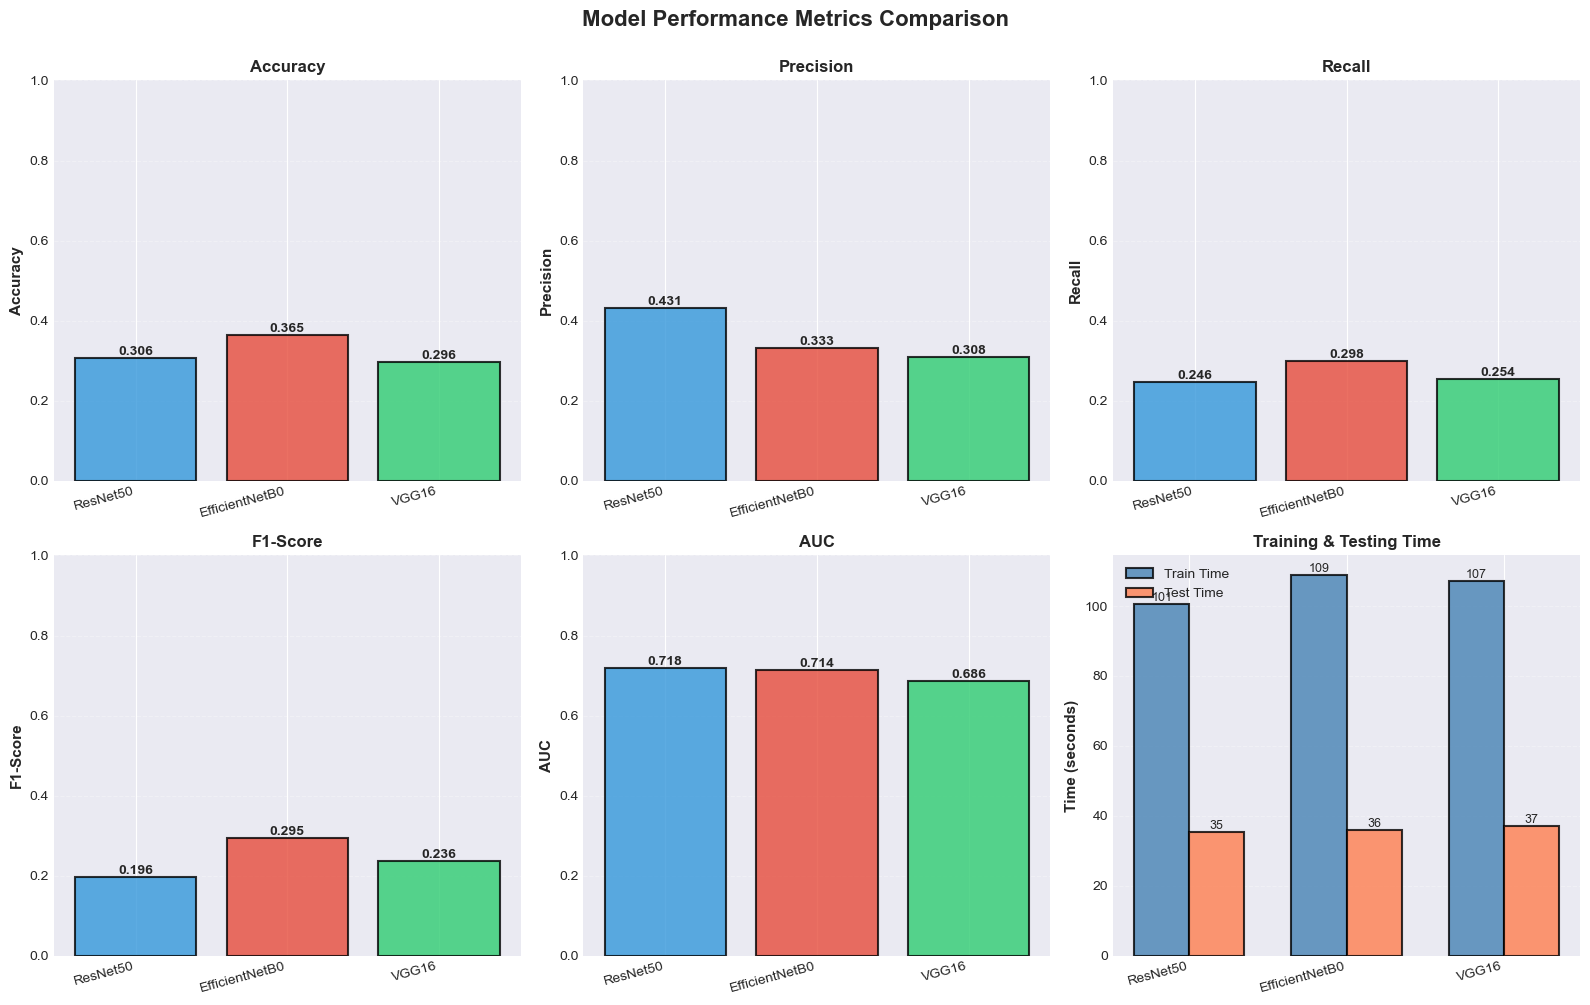


Metrics comparison saved as 'models_metrics_comparison.png'


In [11]:
# Metrics Comparison Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Model Performance Metrics Comparison', fontsize=16, fontweight='bold', y=1.00)

metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

model_names = [results[m]['model'] for m in models]
colors = ['#3498db', '#e74c3c', '#2ecc71']  # Blue, Red, Green

# Plot metrics
for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes.flat[idx]
    values = [results[m][metric] for m in models]
    
    bars = ax.bar(model_names, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Time comparison
ax = axes.flat[5]
train_times = [results[m]['train_time'] for m in models]
test_times = [results[m]['test_time'] for m in models]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, train_times, width, label='Train Time', 
                color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, test_times, width, label='Test Time', 
                color='coral', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
ax.set_title('Training & Testing Time', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('models_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMetrics comparison saved as 'models_metrics_comparison.png'")

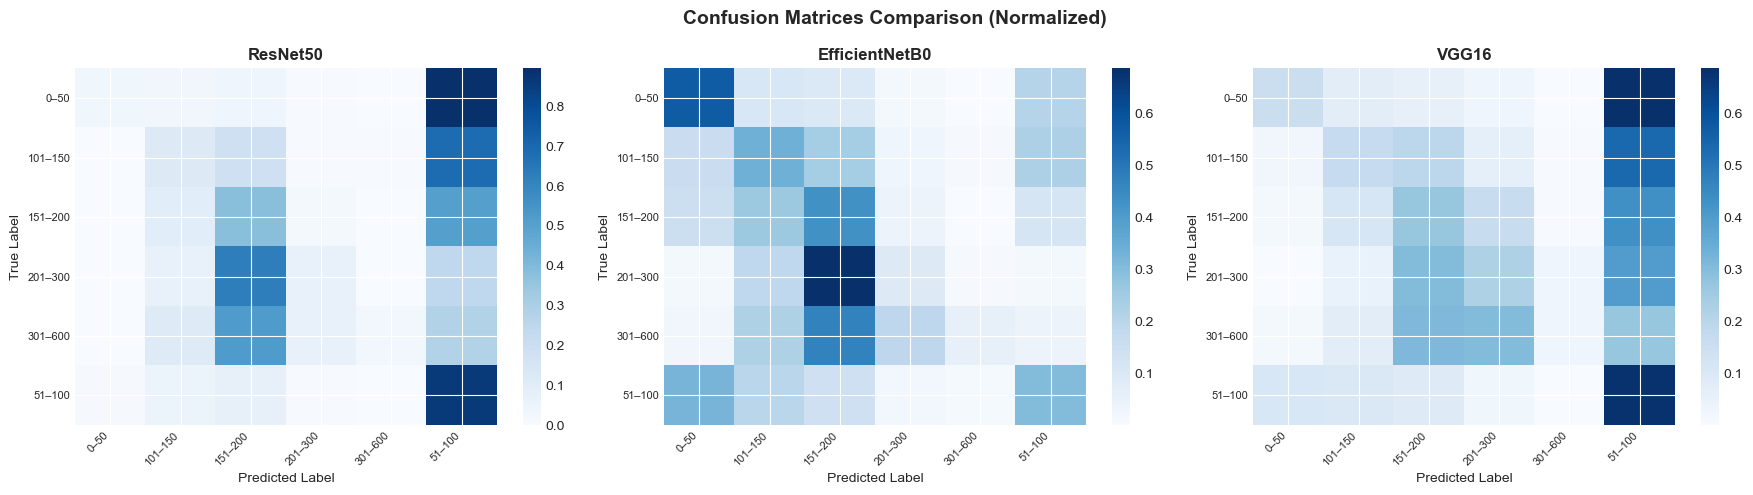

Confusion matrices saved as 'models_confusion_matrices.png'


In [12]:
# Confusion Matrices Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices Comparison (Normalized)', fontsize=14, fontweight='bold')

for idx, model_key in enumerate(models):
    cm = np.array(results[model_key]['confusion_matrix'])
    class_names = list(results[model_key]['class_accuracy'].keys())
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    im = axes[idx].imshow(cm_normalized, cmap='Blues', aspect='auto')
    axes[idx].set_title(f'{results[model_key]["model"]}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xticks(range(len(class_names)))
    axes[idx].set_yticks(range(len(class_names)))
    axes[idx].set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
    axes[idx].set_yticklabels(class_names, fontsize=8)
    
    plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.savefig('models_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrices saved as 'models_confusion_matrices.png'")

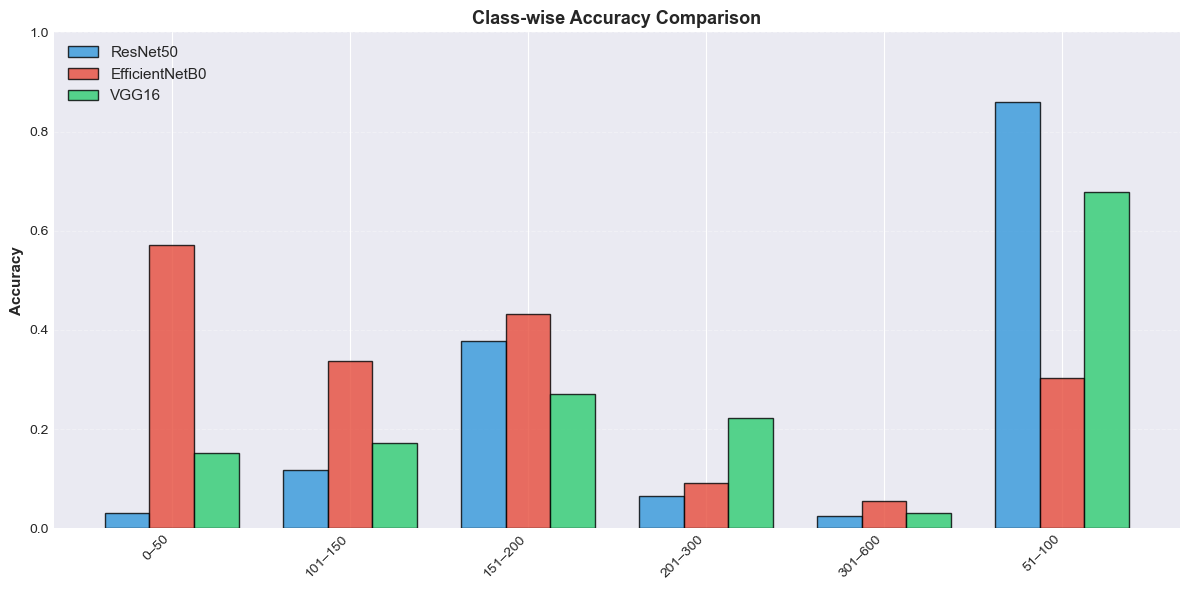

Class accuracy comparison saved as 'class_accuracy_comparison.png'


In [13]:
# Class-wise Accuracy Comparison
fig, ax = plt.subplots(figsize=(12, 6))

class_names = list(results[models[0]]['class_accuracy'].keys())
x = np.arange(len(class_names))
width = 0.25

colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, model_key in enumerate(models):
    class_accs = list(results[model_key]['class_accuracy'].values())
    ax.bar(x + idx*width, class_accs, width, 
           label=results[model_key]['model'], 
           color=colors[idx], alpha=0.8, edgecolor='black', linewidth=1)

ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Class-wise Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend(fontsize=11, loc='best')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('class_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Class accuracy comparison saved as 'class_accuracy_comparison.png'")

In [14]:
# Key Findings and Summary
print(f"\n{'='*90}")
print(f"KEY FINDINGS & SUMMARY")
print(f"{'='*90}\n")

# Extract metrics
metrics_dict = {
    'accuracy': [results[m]['accuracy'] for m in models],
    'precision': [results[m]['precision'] for m in models],
    'recall': [results[m]['recall'] for m in models],
    'f1': [results[m]['f1'] for m in models],
    'auc': [results[m]['auc'] for m in models]
}

model_names_full = [results[m]['model'] for m in models]

print("Best Model by Metric:")
print("-" * 90)
for metric_name, metric_values in metrics_dict.items():
    best_idx = np.argmax(metric_values)
    best_model = model_names_full[best_idx]
    best_value = metric_values[best_idx]
    print(f"  {metric_name.upper():12s}: {best_model:15s} ({best_value:.4f})")

print(f"\nTiming Performance:")
print("-" * 90)
train_times = [results[m]['train_time'] for m in models]
test_times = [results[m]['test_time'] for m in models]
print(f"  Fastest Training: {model_names_full[np.argmin(train_times)]:15s} ({min(train_times):6.2f}s)")
print(f"  Fastest Testing:  {model_names_full[np.argmin(test_times)]:15s} ({min(test_times):6.2f}s)")
print(f"  Slowest Training: {model_names_full[np.argmax(train_times)]:15s} ({max(train_times):6.2f}s)")
print(f"  Slowest Testing:  {model_names_full[np.argmax(test_times)]:15s} ({max(test_times):6.2f}s)")

print(f"\nOverall Statistics:")
print("-" * 90)
for metric_name in ['accuracy', 'f1', 'auc']:
    metric_values = metrics_dict[metric_name]
    print(f"  {metric_name.upper():12s}: Mean={np.mean(metric_values):.4f}, "
          f"Std={np.std(metric_values):.4f}, "
          f"Min={np.min(metric_values):.4f}, "
          f"Max={np.max(metric_values):.4f}")

print(f"\n{'='*90}")


KEY FINDINGS & SUMMARY

Best Model by Metric:
------------------------------------------------------------------------------------------
  ACCURACY    : EfficientNetB0  (0.3653)
  PRECISION   : ResNet50        (0.4307)
  RECALL      : EfficientNetB0  (0.2982)
  F1          : EfficientNetB0  (0.2948)
  AUC         : ResNet50        (0.7182)

Timing Performance:
------------------------------------------------------------------------------------------
  Fastest Training: ResNet50        (100.69s)
  Fastest Testing:  ResNet50        ( 35.44s)
  Slowest Training: EfficientNetB0  (109.01s)
  Slowest Testing:  VGG16           ( 37.12s)

Overall Statistics:
------------------------------------------------------------------------------------------
  ACCURACY    : Mean=0.3227, Std=0.0304, Min=0.2965, Max=0.3653
  F1          : Mean=0.2425, Std=0.0404, Min=0.1965, Max=0.2948
  AUC         : Mean=0.7061, Std=0.0142, Min=0.6862, Max=0.7182



In [15]:
# Save Comparison Results
print(f"\nSaving comparison results...")

# Save to CSV
comparison_df.to_csv('models_comparison_summary.csv', index=False)
print(f"✓ Summary saved to 'models_comparison_summary.csv'")

# Save detailed comparison as JSON
detailed_comparison = {
    'timestamp': pd.Timestamp.now().isoformat(),
    'models': {
        m: results[m] for m in models
    },
    'summary': {
        'best_accuracy': model_names_full[np.argmax([results[m]['accuracy'] for m in models])],
        'best_f1': model_names_full[np.argmax([results[m]['f1'] for m in models])],
        'best_auc': model_names_full[np.argmax([results[m]['auc'] for m in models])],
        'fastest_training': model_names_full[np.argmin([results[m]['train_time'] for m in models])],
        'fastest_inference': model_names_full[np.argmin([results[m]['test_time'] for m in models])]
    }
}

with open('models_comparison_detailed.json', 'w') as f:
    json.dump(detailed_comparison, f, indent=4)
print(f"✓ Detailed comparison saved to 'models_comparison_detailed.json'")

print(f"\nComparison complete! All results have been saved.")


Saving comparison results...
✓ Summary saved to 'models_comparison_summary.csv'
✓ Detailed comparison saved to 'models_comparison_detailed.json'

Comparison complete! All results have been saved.
